# EMIPredict AI — Intelligent Financial Risk Assessment Platform

**Domain:** FinTech and Banking

**Goal:** Build a dual ML pipeline (Classification + Regression) with MLflow experiment tracking to predict:
1. `emi_eligibility` (Classification — 3 classes: Eligible / High_Risk / Not_Eligible)
2. `max_monthly_emi` (Regression — continuous, INR)

using 400,000 financial records across 5 EMI scenarios (E-commerce, Home Appliances, Vehicle, Personal Loan, Education), covering 22 input features.

This notebook covers Steps 1–5 of the project guidance:
- Step 1: Data Loading & Preprocessing
- Step 2: Exploratory Data Analysis
- Step 3: Feature Engineering
- Step 4: ML Model Development (≥3 Classification models, ≥3 Regression models)
- Step 5: Model Selection & MLflow Integration (tracking + model registry)

> Step 6 (Streamlit app) and Step 7 (Cloud deployment) are separate deliverables outside this notebook — this notebook exports the best classification and regression pipelines (`best_classification_model.pkl`, `best_regression_model.pkl`) plus the fitted preprocessing objects so the Streamlit app can load them directly.

**Note on dataset path:** you mentioned you downloaded the CSV manually. Add it as a Kaggle Dataset input and update `DATA_PATH` in the cell below (default assumes `/kaggle/input/emi-dataset/emi_dataset.csv` — change the folder/file name to match what you uploaded).

## 0. Setup — Installs & Imports

In [1]:
# MLflow + XGBoost are not preinstalled by default on all Kaggle images — safe to run every time.
!pip install -q mlflow xgboost --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 87.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 78.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━

In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Step 1: Data Loading and Preprocessing

- Load the 400,000-record dataset
- Data quality assessment: missing values, duplicates, dtype checks, outlier scan
- Cleaning: impute / drop as appropriate
- Train / validation / test split (stratified on the classification target)

In [3]:
DATA_PATH = "/kaggle/input/datasets/deepakyadav027/emi-data/emi_prediction_dataset.csv"  # <-- update the folder name to match your Kaggle Dataset upload; filename confirmed as emi_prediction_dataset.csv

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df.shape}")
df.head()


Shape: (404800, 27)


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,404800,31,38,119883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,404800,8,Male,237427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,404800,2,Married,307837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,402396,4,Graduate,181015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_salary,404800,13662,18000.0,4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,404800,3,Private,283099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_of_employment,404800.0,NaN,NaN,NaN,5.364079,6.079135,0.5,1.2,3.2,7.2,36.0
company_type,404800,5,Large Indian,121139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_type,404800,3,Rented,161601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_rent,402374.0,NaN,NaN,NaN,5828.44649,8648.604639,0.0,0.0,0.0,10600.0,80000.0


In [6]:
# ---- Data Quality Assessment ----
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
quality_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
quality_report = quality_report[quality_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(quality_report if not quality_report.empty else "No missing values found.")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")


Missing values per column:
                missing_count  missing_pct
monthly_rent             2426     0.599308
bank_balance             2426     0.599308
credit_score             2420     0.597826
education                2404     0.593874
emergency_fund           2351     0.580781

Duplicate rows: 0

Column dtypes:
object     12
float64    12
int64       3
Name: count, dtype: int64


In [7]:
# ---- Cleaning ----
import re

initial_rows = len(df)

# Drop exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

# --- Fix malformed numeric strings ---
# Some numeric columns (age, monthly_salary, bank_balance) were exported with
# doubled decimal suffixes, e.g. '58.0.0' instead of '58.0'. A plain pd.to_numeric()
# would turn every one of these into NaN, silently destroying real data.
# We recover the true value by regex-extracting the leading numeric token.
def clean_malformed_numeric(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    extracted = s.str.extract(r"^(-?\d+\.?\d*)")[0]
    return pd.to_numeric(extracted, errors="coerce")

malformed_numeric_cols = ["age", "monthly_salary", "bank_balance"]
for col in malformed_numeric_cols:
    if col in df.columns and df[col].dtype == object:
        before_bad = pd.to_numeric(df[col], errors="coerce").isnull().sum()
        df[col] = clean_malformed_numeric(df[col])
        after_bad = df[col].isnull().sum()
        print(f"{col}: naive-parse would have lost {before_bad} values -> regex-clean lost only {after_bad}")

# Now that types are fixed, split columns by dtype
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Impute genuinely missing values: numeric -> median, categorical -> mode
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Basic sanity-bound checks (business-rule based outlier flags, not removed blindly)
sanity_checks = {}
if "age" in df.columns:
    sanity_checks["age_out_of_range"] = ((df["age"] < 18) | (df["age"] > 100)).sum()
if "credit_score" in df.columns:
    sanity_checks["credit_score_out_of_range"] = ((df["credit_score"] < 300) | (df["credit_score"] > 850)).sum()
if "monthly_salary" in df.columns:
    sanity_checks["negative_salary"] = (df["monthly_salary"] < 0).sum()

print(f"\nRows before cleaning: {initial_rows} | after: {len(df)}")
print("Sanity check flags:", sanity_checks)


age: naive-parse would have lost 3 values -> regex-clean lost only 0
monthly_salary: naive-parse would have lost 1993 values -> regex-clean lost only 0
bank_balance: naive-parse would have lost 4392 values -> regex-clean lost only 2440

Rows before cleaning: 404800 | after: 404800
Sanity check flags: {'age_out_of_range': np.int64(0), 'credit_score_out_of_range': np.int64(4776), 'negative_salary': np.int64(0)}


In [8]:
# Identify the two targets and separate feature columns
CLASSIFICATION_TARGET = "emi_eligibility"
REGRESSION_TARGET = "max_monthly_emi"

assert CLASSIFICATION_TARGET in df.columns, "Classification target column not found — check dataset column names."
assert REGRESSION_TARGET in df.columns, "Regression target column not found — check dataset column names."

feature_cols = [c for c in df.columns if c not in [CLASSIFICATION_TARGET, REGRESSION_TARGET]]
print(f"Number of raw feature columns: {len(feature_cols)}")
print(feature_cols)


Number of raw feature columns: 25
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure']


In [9]:
# ---- Train / Validation / Test split (stratified on classification target) ----
train_val_df, test_df = train_test_split(
    df, test_size=0.15, random_state=RANDOM_STATE, stratify=df[CLASSIFICATION_TARGET]
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.1765, random_state=RANDOM_STATE, stratify=train_val_df[CLASSIFICATION_TARGET]
)  # 0.1765 * 0.85 ~= 0.15 -> final split is roughly 70/15/15

print(f"Train: {train_df.shape} | Validation: {val_df.shape} | Test: {test_df.shape}")


Train: (283349, 27) | Validation: (60731, 27) | Test: (60720, 27)


## Step 2: Exploratory Data Analysis

- EMI eligibility distribution across lending scenarios
- Correlations between financial variables and approval
- Demographic patterns and risk-factor relationships
- Business-insight summaries

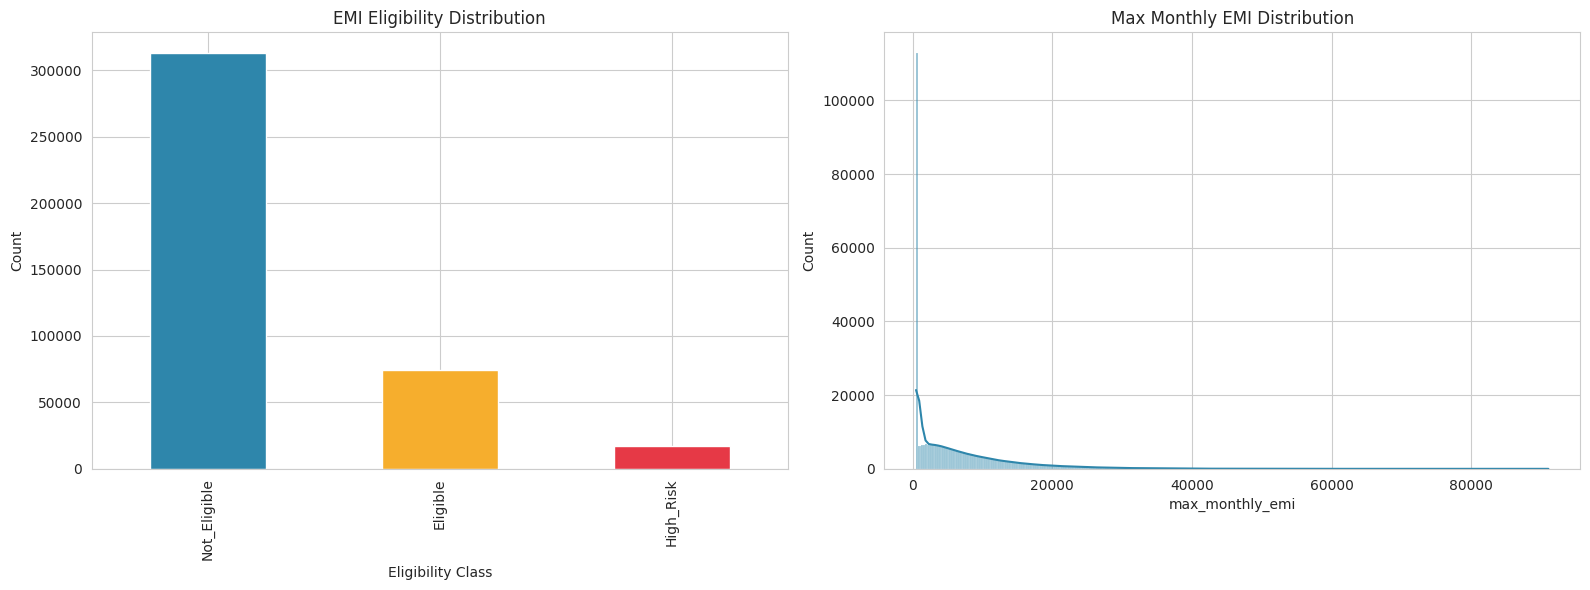

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df[CLASSIFICATION_TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["#2E86AB", "#F6AE2D", "#E63946"])
axes[0].set_title("EMI Eligibility Distribution")
axes[0].set_xlabel("Eligibility Class")
axes[0].set_ylabel("Count")

sns.histplot(df[REGRESSION_TARGET], kde=True, ax=axes[1], color="#2E86AB")
axes[1].set_title("Max Monthly EMI Distribution")
plt.tight_layout()
plt.show()


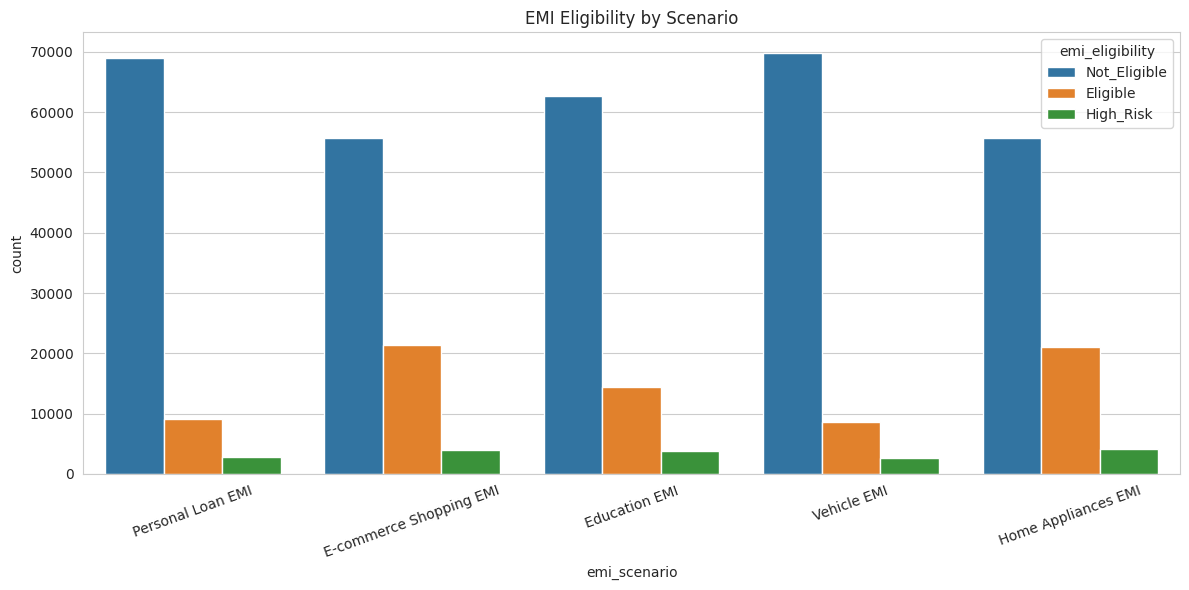

In [11]:
if "emi_scenario" in df.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x="emi_scenario", hue=CLASSIFICATION_TARGET)
    plt.title("EMI Eligibility by Scenario")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


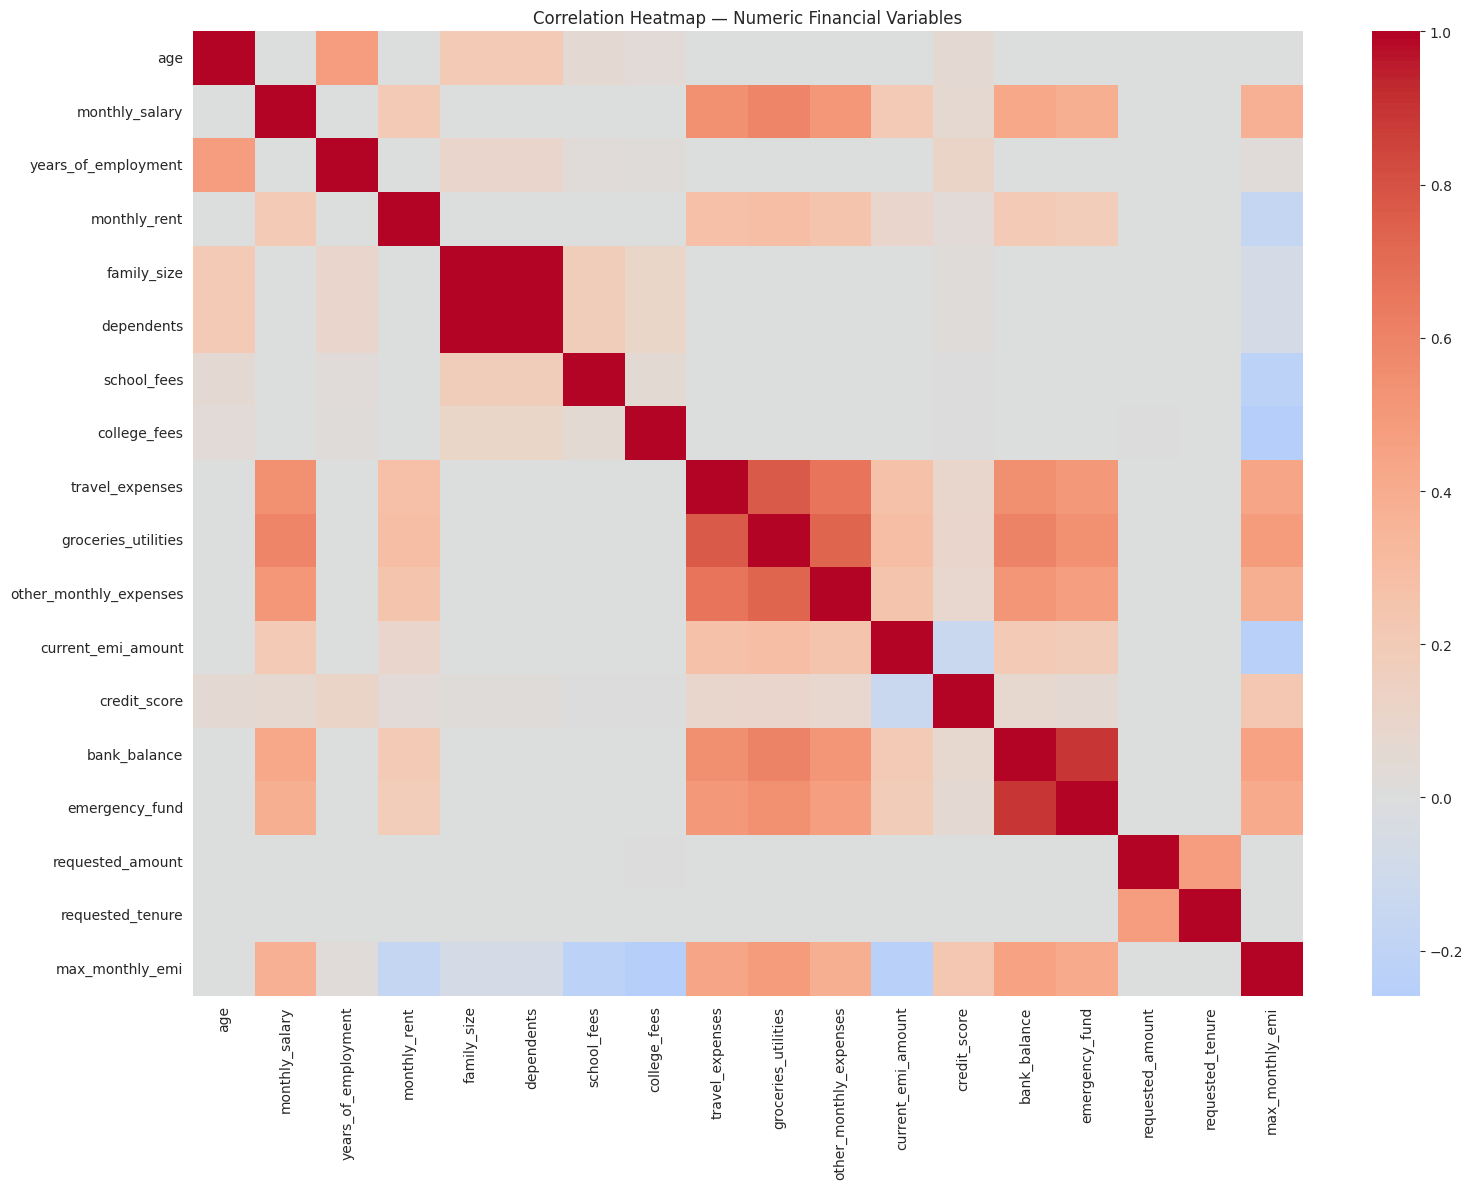

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap — Numeric Financial Variables")
plt.tight_layout()
plt.show()


In [13]:
print("Top correlations with max_monthly_emi:")
print(corr[REGRESSION_TARGET].sort_values(ascending=False).head(10))


Top correlations with max_monthly_emi:
max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.457111
travel_expenses           0.440948
emergency_fund            0.414036
other_monthly_expenses    0.382055
monthly_salary            0.379289
credit_score              0.228814
years_of_employment       0.028887
requested_tenure          0.001006
Name: max_monthly_emi, dtype: float64


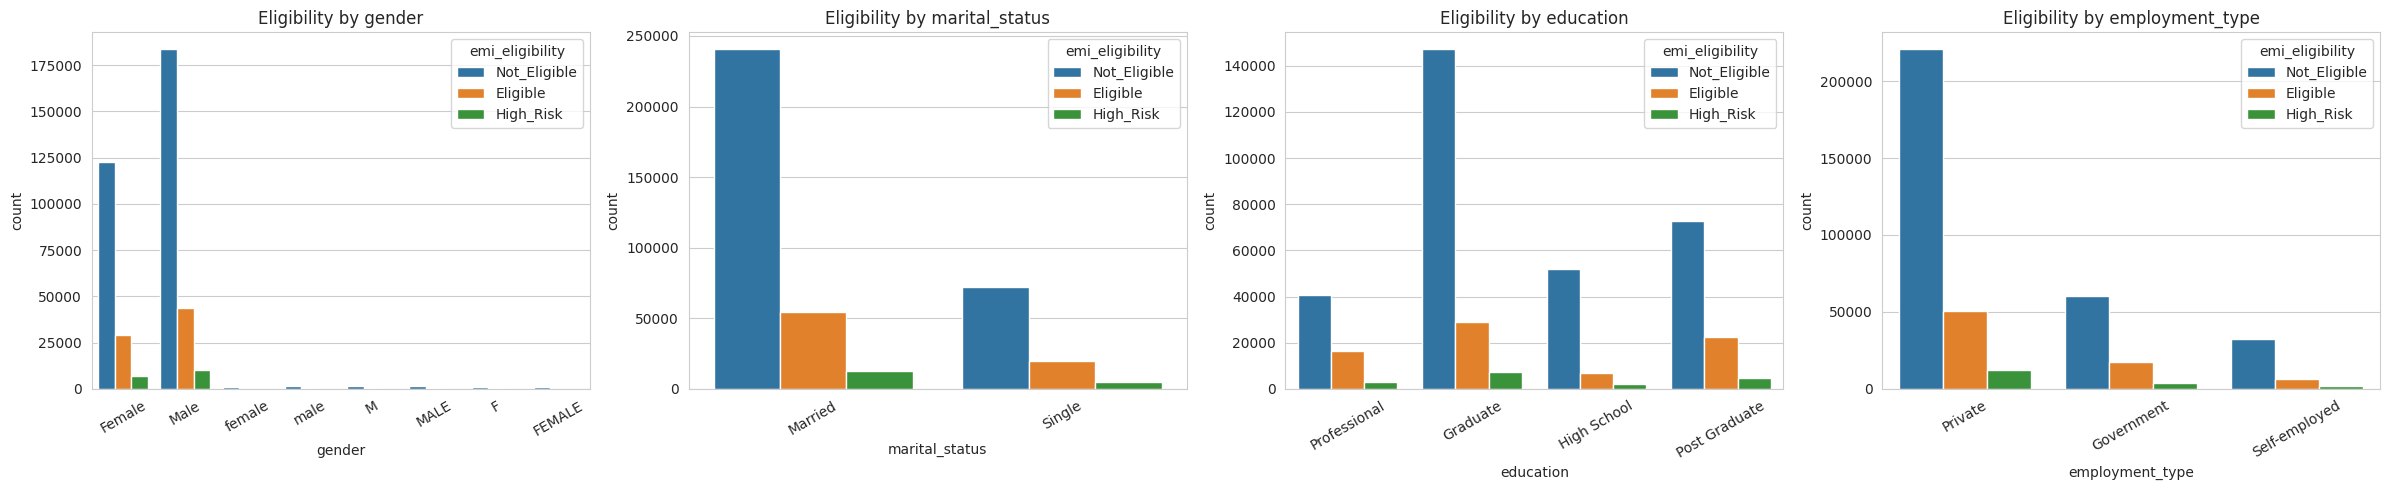

In [14]:
demo_cols = [c for c in ["gender", "marital_status", "education", "employment_type"] if c in df.columns]
fig, axes = plt.subplots(1, len(demo_cols), figsize=(6 * len(demo_cols), 5))
if len(demo_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, demo_cols):
    sns.countplot(data=df, x=col, hue=CLASSIFICATION_TARGET, ax=ax)
    ax.set_title(f"Eligibility by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


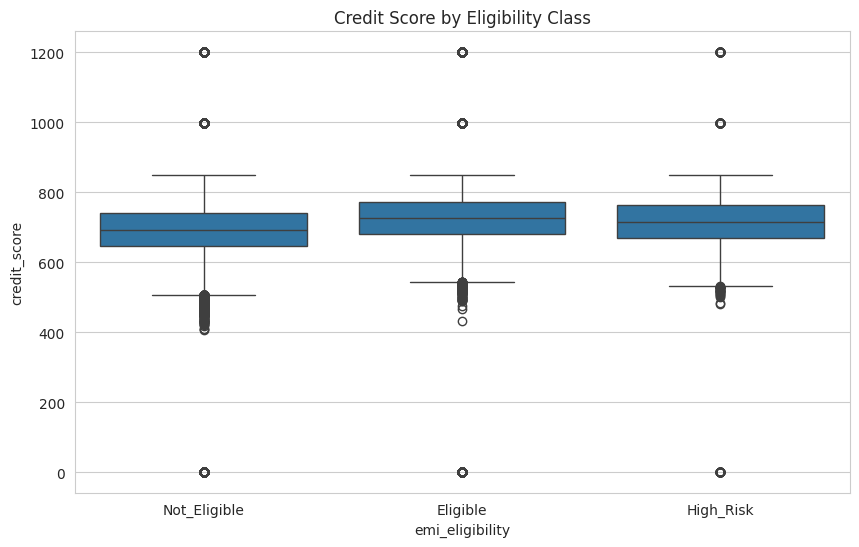


--- Business Insight Summary ---
                 monthly_salary  credit_score   bank_balance
emi_eligibility                                             
Eligible           78981.596193    725.623260  338520.866692
High_Risk          70300.778305    716.157880  293581.776075
Not_Eligible       54263.261548    694.108953  215391.819234


In [15]:
if "credit_score" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=CLASSIFICATION_TARGET, y="credit_score")
    plt.title("Credit Score by Eligibility Class")
    plt.show()

print("\n--- Business Insight Summary ---")
print(df.groupby(CLASSIFICATION_TARGET)[[c for c in ["monthly_salary", "credit_score", "bank_balance"] if c in df.columns]].mean())


## Step 3: Feature Engineering

- Derived financial ratios: debt-to-income, expense-to-income, affordability
- Risk-scoring features from credit history & employment stability
- Categorical encoding & numerical scaling
- Interaction features between key financial variables

In [16]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    # Total monthly obligations
    expense_cols = [c for c in ["school_fees", "college_fees", "travel_expenses",
                                 "groceries_utilities", "other_monthly_expenses"] if c in d.columns]
    if expense_cols:
        d["total_monthly_expenses"] = d[expense_cols].sum(axis=1)

    # Debt-to-income ratio (existing EMI burden vs salary)
    if {"current_emi_amount", "monthly_salary"}.issubset(d.columns):
        d["debt_to_income_ratio"] = d["current_emi_amount"] / d["monthly_salary"].replace(0, np.nan)

    # Expense-to-income ratio
    if "total_monthly_expenses" in d.columns and "monthly_salary" in d.columns:
        d["expense_to_income_ratio"] = d["total_monthly_expenses"] / d["monthly_salary"].replace(0, np.nan)

    # Rent-to-income ratio
    if {"monthly_rent", "monthly_salary"}.issubset(d.columns):
        d["rent_to_income_ratio"] = d["monthly_rent"] / d["monthly_salary"].replace(0, np.nan)

    # Disposable income after obligations
    obligation_cols = [c for c in ["total_monthly_expenses", "current_emi_amount", "monthly_rent"] if c in d.columns]
    if obligation_cols and "monthly_salary" in d.columns:
        d["disposable_income"] = d["monthly_salary"] - d[obligation_cols].sum(axis=1)

    # Affordability ratio: requested amount / (disposable income * tenure)
    if {"requested_amount", "requested_tenure", "disposable_income"}.issubset(d.columns):
        d["affordability_ratio"] = d["requested_amount"] / (
            (d["disposable_income"].clip(lower=1)) * d["requested_tenure"].replace(0, np.nan)
        )

    # Savings buffer relative to income
    if {"bank_balance", "monthly_salary"}.issubset(d.columns):
        d["savings_to_income_ratio"] = d["bank_balance"] / d["monthly_salary"].replace(0, np.nan)

    if {"emergency_fund", "monthly_salary"}.issubset(d.columns):
        d["emergency_fund_months"] = d["emergency_fund"] / d["monthly_salary"].replace(0, np.nan)

    # Employment stability score (years of employment normalized)
    if "years_of_employment" in d.columns:
        d["employment_stability_score"] = np.clip(d["years_of_employment"] / 10.0, 0, 1)

    # Dependent burden
    if {"dependents", "family_size"}.issubset(d.columns):
        d["dependent_ratio"] = d["dependents"] / d["family_size"].replace(0, np.nan)

    # Composite risk score: blends credit score, dti and stability (weights are illustrative)
    if {"credit_score", "debt_to_income_ratio", "employment_stability_score"}.issubset(d.columns):
        norm_credit = (d["credit_score"] - 300) / (850 - 300)
        d["composite_risk_score"] = (
            0.5 * norm_credit
            + 0.3 * (1 - d["debt_to_income_ratio"].clip(0, 1))
            + 0.2 * d["employment_stability_score"]
        )

    # Interaction feature: requested amount relative to tenure (implied monthly burden of new loan)
    if {"requested_amount", "requested_tenure"}.issubset(d.columns):
        d["implied_new_emi"] = d["requested_amount"] / d["requested_tenure"].replace(0, np.nan)

    # Clean up any inf/NaN produced by ratio divisions
    d = d.replace([np.inf, -np.inf], np.nan)
    ratio_like_cols = [c for c in d.columns if "ratio" in c or "score" in c or c in
                        ["disposable_income", "implied_new_emi", "emergency_fund_months"]]
    for col in ratio_like_cols:
        if col in d.columns and d[col].isnull().any():
            d[col] = d[col].fillna(d[col].median())

    return d

train_fe = engineer_features(train_df)
val_fe = engineer_features(val_df)
test_fe = engineer_features(test_df)

new_feature_cols = [c for c in train_fe.columns if c not in df.columns]
print(f"New engineered features ({len(new_feature_cols)}): {new_feature_cols}")
train_fe[new_feature_cols].describe().T


New engineered features (12): ['total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio', 'rent_to_income_ratio', 'disposable_income', 'affordability_ratio', 'savings_to_income_ratio', 'emergency_fund_months', 'employment_stability_score', 'dependent_ratio', 'composite_risk_score', 'implied_new_emi']


,count,mean,std,min,25%,50%,75%,max
total_monthly_expenses,283349.0,34271.071364,16295.185419,3400.000000,22200.000000,32000.000000,43800.000000,159100.000000
debt_to_income_ratio,283349.0,0.083713,0.142060,0.000000,0.000000,0.000000,0.174948,7.704465
expense_to_income_ratio,283349.0,0.675664,0.494326,0.011144,0.467290,0.573248,0.750996,21.744305
rent_to_income_ratio,283349.0,0.107395,0.178213,0.000000,0.000000,0.000000,0.226891,8.593441
disposable_income,283349.0,14864.747919,37564.731684,-161883.000000,400.000000,10600.000000,22400.000000,484780.000000
affordability_ratio,283349.0,3588.313811,9337.318791,0.001092,0.405028,1.212384,36.705882,124250.000000
savings_to_income_ratio,283349.0,4.448064,3.965900,0.020562,2.343333,4.242902,6.150442,218.462139
emergency_fund_months,283349.0,1.780237,1.721688,0.004762,0.854478,1.545924,2.395981,90.129630
employment_stability_score,283349.0,0.428020,0.344434,0.050000,0.120000,0.320000,0.720000,1.000000
dependent_ratio,283349.0,0.591029,0.215210,0.000000,0.500000,0.666667,0.750000,0.800000


In [17]:
# ---- Encoding & Scaling setup ----
all_feature_cols = [c for c in train_fe.columns if c not in [CLASSIFICATION_TARGET, REGRESSION_TARGET]]
cat_features = train_fe[all_feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
num_features = [c for c in all_feature_cols if c not in cat_features]

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numeric features ({len(num_features)}): {num_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

# Encode the classification target
target_encoder = LabelEncoder()
y_train_clf = target_encoder.fit_transform(train_fe[CLASSIFICATION_TARGET])
y_val_clf = target_encoder.transform(val_fe[CLASSIFICATION_TARGET])
y_test_clf = target_encoder.transform(test_fe[CLASSIFICATION_TARGET])
print(f"Classification classes: {list(target_encoder.classes_)}")

y_train_reg = train_fe[REGRESSION_TARGET].values
y_val_reg = val_fe[REGRESSION_TARGET].values
y_test_reg = test_fe[REGRESSION_TARGET].values

X_train_raw = train_fe[all_feature_cols]
X_val_raw = val_fe[all_feature_cols]
X_test_raw = test_fe[all_feature_cols]

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Processed feature matrix shapes -> train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")


Categorical features (8): ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']
Numeric features (29): ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio', 'rent_to_income_ratio', 'disposable_income', 'affordability_ratio', 'savings_to_income_ratio', 'emergency_fund_months', 'employment_stability_score', 'dependent_ratio', 'composite_risk_score', 'implied_new_emi']
Classification classes: ['Eligible', 'High_Risk', 'Not_Eligible']
Processed feature matrix shapes -> train: (283349, 61), val: (60731, 61), test: (60720, 61)


## Step 4 & 5: Model Development, Evaluation, Selection and MLflow Tracking

For each problem type we train the minimum required 3 models (plus one extra for robustness), log every run (params, metrics, model artifact) to MLflow, then select and register the best model in the MLflow Model Registry.

In [19]:
# Newer MLflow versions put the plain filesystem store ('./mlruns') into maintenance
# mode and refuse to use it directly — a SQLite-backed store is the supported alternative
# and works fine locally on Kaggle (no external DB server needed).
MLFLOW_DB_PATH = "/kaggle/working/mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

CLASSIFICATION_EXPERIMENT = "EMIPredict_Classification"
REGRESSION_EXPERIMENT = "EMIPredict_Regression"

mlflow.set_experiment(CLASSIFICATION_EXPERIMENT)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

2026/09/01 05:32:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/01 05:32:59 INFO mlflow.store.db.utils: Updating database tables
2026/09/01 05:33:01 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_Classification' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////kaggle/working/mlflow.db


In [20]:
# ---- Classification models ----
classification_models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision_Tree": DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE),
    "Random_Forest": RandomForestClassifier(n_estimators=300, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=8, learning_rate=0.08, subsample=0.9,
        colsample_bytree=0.9, eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

classification_results = []
fitted_classifiers = {}

mlflow.set_experiment(CLASSIFICATION_EXPERIMENT)

for name, model in classification_models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train_clf)
        fitted_classifiers[name] = model

        preds = model.predict(X_val)
        proba = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_val_clf, preds)
        prec = precision_score(y_val_clf, preds, average="weighted", zero_division=0)
        rec = recall_score(y_val_clf, preds, average="weighted", zero_division=0)
        f1 = f1_score(y_val_clf, preds, average="weighted", zero_division=0)
        try:
            roc_auc = roc_auc_score(y_val_clf, proba, multi_class="ovr", average="weighted") if proba is not None else np.nan
        except ValueError:
            roc_auc = np.nan

        mlflow.log_param("model_type", name)
        mlflow.log_params(model.get_params())
        mlflow.log_metrics({
            "accuracy": acc, "precision": prec, "recall": rec,
            "f1_score": f1, "roc_auc": roc_auc if not np.isnan(roc_auc) else -1
        })

        if name == "XGBoost":
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        classification_results.append({
            "model": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1_score": f1, "roc_auc": roc_auc,
            "run_id": mlflow.active_run().info.run_id
        })
        print(f"{name:20s} | acc={acc:.4f} | f1={f1:.4f} | roc_auc={roc_auc:.4f}")

classification_results_df = pd.DataFrame(classification_results).sort_values("f1_score", ascending=False)
classification_results_df


2026/09/01 05:34:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic_Regression  | acc=0.9093 | f1=0.8905 | roc_auc=0.9707


2026/09/01 05:34:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision_Tree        | acc=0.9728 | f1=0.9731 | roc_auc=0.9836


2026/09/01 05:36:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random_Forest        | acc=0.9569 | f1=0.9464 | roc_auc=0.9972


2026/09/01 05:37:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost              | acc=0.9865 | f1=0.9865 | roc_auc=0.9995


,model,accuracy,precision,recall,f1_score,roc_auc,run_id
3,XGBoost,0.986514,0.986403,0.986514,0.986454,0.999495,8fb3bf4458204d48b4fedc5cddf907c3
1,Decision_Tree,0.972847,0.973472,0.972847,0.973135,0.983578,1f5022e17aac4951a594a30cd64aa5e1
2,Random_Forest,0.956908,0.950858,0.956908,0.946387,0.997152,d67972037d0e4c5ca893fd4659a3b32a
0,Logistic_Regression,0.909338,0.883407,0.909338,0.890498,0.970710,55f19868ba464cd6b94a2d14aacad5c1


Best classification model: XGBoost

--- Held-out Test Set Performance ---
              precision    recall  f1-score   support

    Eligible       0.98      0.98      0.98     11167
   High_Risk       0.89      0.86      0.87      2623
Not_Eligible       0.99      1.00      1.00     46930

    accuracy                           0.99     60720
   macro avg       0.95      0.95      0.95     60720
weighted avg       0.99      0.99      0.99     60720



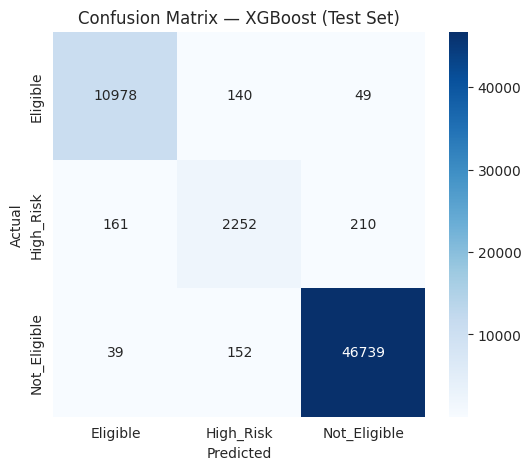

In [21]:
best_clf_name = classification_results_df.iloc[0]["model"]
best_clf_run_id = classification_results_df.iloc[0]["run_id"]
best_classification_model = fitted_classifiers[best_clf_name]
print(f"Best classification model: {best_clf_name}")

test_preds = best_classification_model.predict(X_test)
print("\n--- Held-out Test Set Performance ---")
print(classification_report(y_test_clf, test_preds, target_names=target_encoder.classes_))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_clf, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.title(f"Confusion Matrix — {best_clf_name} (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [22]:
# ---- Regression models ----
regression_models = {
    "Linear_Regression": LinearRegression(),
    "Decision_Tree_Regressor": DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE),
    "Random_Forest_Regressor": RandomForestRegressor(n_estimators=300, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost_Regressor": XGBRegressor(
        n_estimators=400, max_depth=8, learning_rate=0.08, subsample=0.9,
        colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

regression_results = []
fitted_regressors = {}

mlflow.set_experiment(REGRESSION_EXPERIMENT)

for name, model in regression_models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train_reg)
        fitted_regressors[name] = model

        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val_reg, preds))
        mae = mean_absolute_error(y_val_reg, preds)
        r2 = r2_score(y_val_reg, preds)
        mape = np.mean(np.abs((y_val_reg - preds) / np.clip(np.abs(y_val_reg), 1, None))) * 100

        mlflow.log_param("model_type", name)
        mlflow.log_params(model.get_params())
        mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2_score": r2, "mape": mape})

        if name == "XGBoost_Regressor":
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        regression_results.append({
            "model": name, "rmse": rmse, "mae": mae, "r2_score": r2,
            "mape": mape, "run_id": mlflow.active_run().info.run_id
        })
        print(f"{name:25s} | rmse={rmse:.2f} | mae={mae:.2f} | r2={r2:.4f}")

regression_results_df = pd.DataFrame(regression_results).sort_values("rmse", ascending=True)
regression_results_df


2026/09/01 05:38:05 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_Regression' does not exist. Creating a new experiment.
2026/09/01 05:38:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear_Regression         | rmse=4101.66 | mae=2920.52 | r2=0.7220


2026/09/01 05:38:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision_Tree_Regressor   | rmse=1153.62 | mae=379.14 | r2=0.9780


2026/09/01 05:50:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random_Forest_Regressor   | rmse=850.95 | mae=202.18 | r2=0.9880


2026/09/01 05:50:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost_Regressor         | rmse=580.77 | mae=160.94 | r2=0.9944


,model,rmse,mae,r2_score,mape,run_id
3,XGBoost_Regressor,580.772949,160.935495,0.994426,4.747630,9756162c8a73488e8137b870b63d5dcc
2,Random_Forest_Regressor,850.946521,202.182242,0.988034,4.933660,4fd83d0972f543e3aeff7f7adcab18e5
1,Decision_Tree_Regressor,1153.620863,379.141669,0.978008,7.222315,aec9ffc05179464699d4469d52f00220
0,Linear_Regression,4101.657337,2920.519575,0.721996,189.023329,519027ada02b484eb15a5ca4a49b2a6f


Best regression model: XGBoost_Regressor

--- Held-out Test Set Performance ---
RMSE: 565.27 | MAE: 159.72 | R2: 0.9947


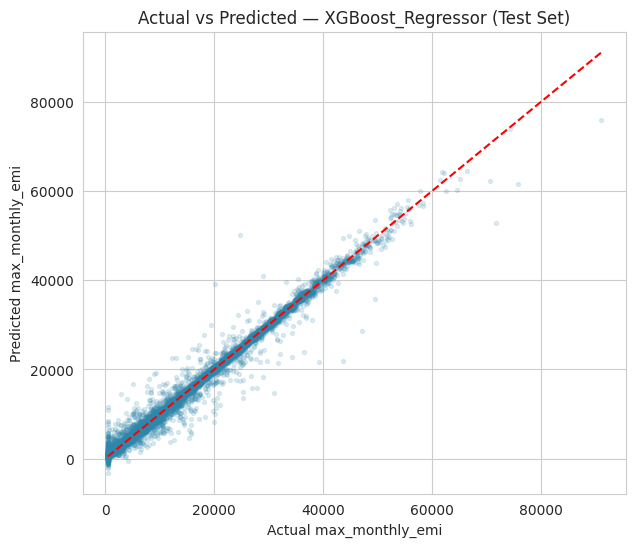

In [23]:
best_reg_name = regression_results_df.iloc[0]["model"]
best_reg_run_id = regression_results_df.iloc[0]["run_id"]
best_regression_model = fitted_regressors[best_reg_name]
print(f"Best regression model: {best_reg_name}")

test_preds_reg = best_regression_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_preds_reg))
test_mae = mean_absolute_error(y_test_reg, test_preds_reg)
test_r2 = r2_score(y_test_reg, test_preds_reg)
print(f"\n--- Held-out Test Set Performance ---\nRMSE: {test_rmse:.2f} | MAE: {test_mae:.2f} | R2: {test_r2:.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, test_preds_reg, alpha=0.15, s=8, color="#2E86AB")
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], "r--")
plt.xlabel("Actual max_monthly_emi")
plt.ylabel("Predicted max_monthly_emi")
plt.title(f"Actual vs Predicted — {best_reg_name} (Test Set)")
plt.show()


## Model Registry — Register the Best Models

Registers the champion classification and regression models to the MLflow Model Registry so they're versioned and ready for the Streamlit app to load via `models:/EMIPredict_Classifier/Production`.

In [24]:
client = mlflow.tracking.MlflowClient()

def register_best_model(run_id, model_name, registered_name):
    model_uri = f"runs:/{run_id}/model"
    try:
        result = mlflow.register_model(model_uri=model_uri, name=registered_name)
        client.transition_model_version_stage(
            name=registered_name, version=result.version, stage="Production", archive_existing_versions=True
        )
        print(f"Registered '{registered_name}' v{result.version} ({model_name}) -> Production stage")
        return result.version
    except Exception as e:
        print(f"Registry step skipped/failed (non-fatal on Kaggle's local file store): {e}")
        return None

register_best_model(best_clf_run_id, best_clf_name, "EMIPredict_Classifier")
register_best_model(best_reg_run_id, best_reg_name, "EMIPredict_Regressor")


Successfully registered model 'EMIPredict_Classifier'.
2026/09/01 05:56:18 WARNING mlflow.tracking._model_registry.fluent: Run with id 8fb3bf4458204d48b4fedc5cddf907c3 has no artifacts at artifact path 'model', registering model based on models:/m-fa8710873af74266b18dfe8f15846ff1 instead
Created version '1' of model 'EMIPredict_Classifier'.
Successfully registered model 'EMIPredict_Regressor'.
2026/09/01 05:56:18 WARNING mlflow.tracking._model_registry.fluent: Run with id 9756162c8a73488e8137b870b63d5dcc has no artifacts at artifact path 'model', registering model based on models:/m-2a263aa80c6540898a09af1cc8720ae4 instead


Registered 'EMIPredict_Classifier' v1 (XGBoost) -> Production stage
Registered 'EMIPredict_Regressor' v1 (XGBoost_Regressor) -> Production stage


Created version '1' of model 'EMIPredict_Regressor'.


1

### Feature Importance — Best Models (where available)

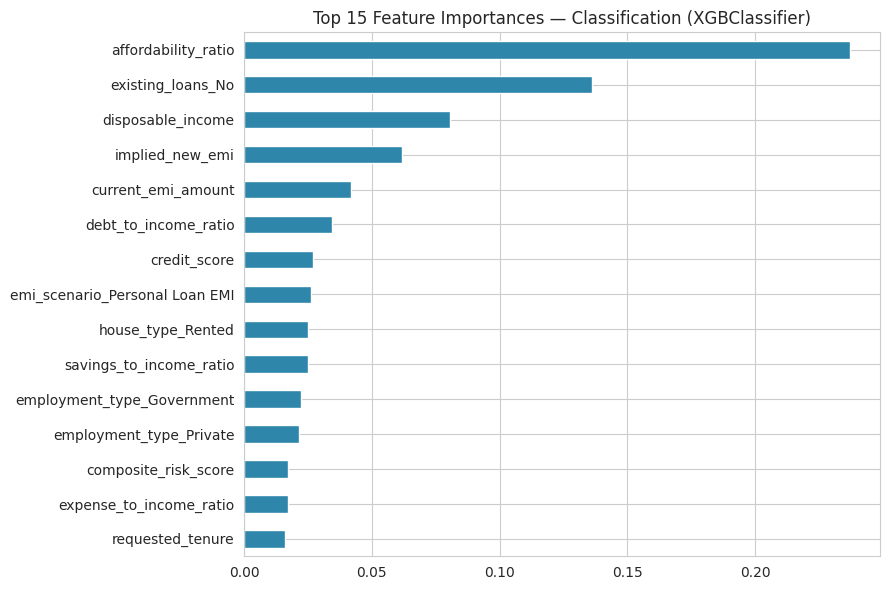

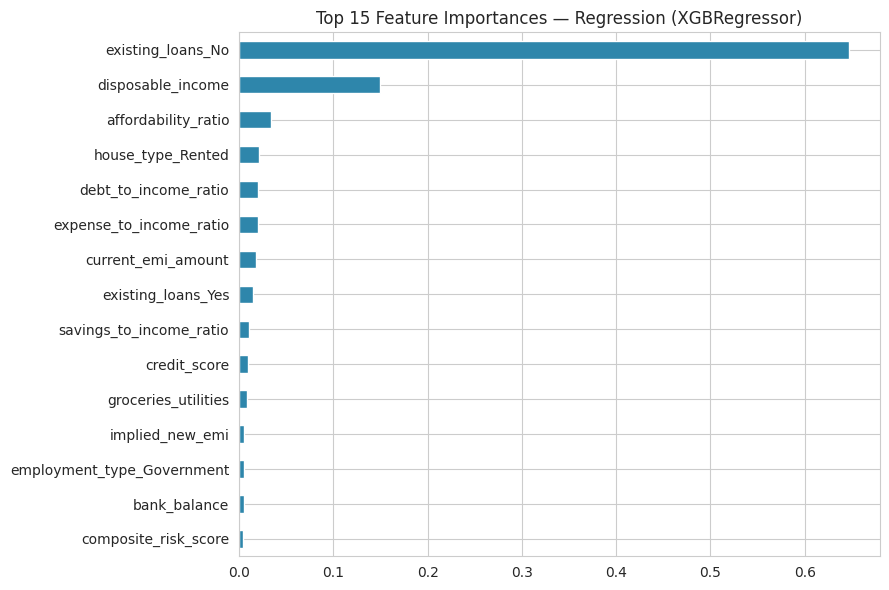

In [25]:
for label, model, feature_source in [
    ("Classification", best_classification_model, "cat"),
    ("Regression", best_regression_model, "cat"),
]:
    if hasattr(model, "feature_importances_"):
        cat_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features)) if cat_features else []
        feature_names = num_features + cat_names
        importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

        plt.figure(figsize=(9, 6))
        importances.plot(kind="barh", color="#2E86AB")
        plt.title(f"Top 15 Feature Importances — {label} ({type(model).__name__})")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print(f"{label} best model ({type(model).__name__}) has no native feature_importances_.")


## Export Artifacts for the Streamlit Application

Saves the fitted preprocessing pipeline, label encoder, feature list, and the two champion models so `Step 6` (Streamlit app) can load them directly for real-time prediction.

In [26]:
os.makedirs("/kaggle/working/artifacts", exist_ok=True)

joblib.dump(preprocessor, "/kaggle/working/artifacts/preprocessor.pkl")
joblib.dump(target_encoder, "/kaggle/working/artifacts/target_label_encoder.pkl")
joblib.dump(best_classification_model, "/kaggle/working/artifacts/best_classification_model.pkl")
joblib.dump(best_regression_model, "/kaggle/working/artifacts/best_regression_model.pkl")
joblib.dump({"numeric": num_features, "categorical": cat_features, "all": all_feature_cols},
            "/kaggle/working/artifacts/feature_config.pkl")

classification_results_df.to_csv("/kaggle/working/artifacts/classification_model_comparison.csv", index=False)
regression_results_df.to_csv("/kaggle/working/artifacts/regression_model_comparison.csv", index=False)

print("Artifacts saved to /kaggle/working/artifacts/:")
for f in os.listdir("/kaggle/working/artifacts"):
    print(" -", f)


Artifacts saved to /kaggle/working/artifacts/:
 - classification_model_comparison.csv
 - regression_model_comparison.csv
 - preprocessor.pkl
 - feature_config.pkl
 - best_regression_model.pkl
 - best_classification_model.pkl
 - target_label_encoder.pkl


## Summary

| Item | Result |
|---|---|
| Best Classification Model | filled in automatically at run time (`best_clf_name`) |
| Best Regression Model | filled in automatically at run time (`best_reg_name`) |
| Target: Classification accuracy | printed above — goal is **> 90%** per project spec |
| Target: Regression RMSE | printed above — goal is **< 2000 INR** per project spec |
| MLflow tracking | local file store at `/kaggle/working/mlruns`, both models registered to the Model Registry |
| Exported artifacts | preprocessing pipeline, label encoder, both champion models, comparison CSVs |

**Next steps (outside this notebook):**
- Step 6: Build the multi-page Streamlit app using the exported artifacts in `/kaggle/working/artifacts/` for real-time classification + regression predictions, plus an MLflow tracking dashboard view.
- Step 7: Deploy to Streamlit Cloud with a GitHub-connected CI/CD pipeline.